<a href="https://colab.research.google.com/github/avishek-astra/Deep_Learning_Experiments/blob/main/TransferLearning_codechallenge_letters2numbers_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#IMPORT LIBRARIES
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset
import copy
from sklearn.model_selection import train_test_split
#form importing data
import torchvision

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
#use gpu if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

Import and inspect the data

In [3]:
#download the dataset
letterdata=torchvision.datasets.EMNIST(root='emnist',split='letters',download=True)
numberdata=torchvision.datasets.EMNIST(root='emnist',split='digits',download=True)

100%|██████████| 562M/562M [00:05<00:00, 107MB/s]


In [5]:
#so therefore we'll eliminate it and subtract 1 from the original
#remove the first class category
letterCategories=letterdata.classes[1:]
#relabel label to start to 0
labels=copy.deepcopy(letterdata.targets)-1

#transform to 4D tensors for conv layers (and transform form int8 to float)
letterImages=letterdata.data.view([letterdata.data.shape[0],1,28,28]).float()
letterImages/=torch.max(letterImages)
#step 2: use scikitlearn to split the data
train_data,test_data,train_labels,test_labels=train_test_split(letterImages,labels,test_size=.1)
#step3:convert into pytorch Datasets
train_data=TensorDataset(train_data,train_labels)
test_data=TensorDataset(test_data,test_labels)

#step 4:translate into dataloader objects
batchsize=32
letter_train_loader=DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
letter_test_loader=DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

In [8]:
#transform to 4D tensors for conv layers (and transform form int8 to float)
numberImages=numberdata.data.view([numberdata.data.shape[0],1,28,28]).float()
numberImages/=torch.max(numberImages)
#step 2: use scikitlearn to split the data
train_data,test_data,train_labels,test_labels=train_test_split(numberImages,numberdata.targets,test_size=.1)
#step3:convert into pytorch Datasets
train_data=TensorDataset(train_data,train_labels)
test_data=TensorDataset(test_data,test_labels)

#step 4:translate into dataloader objects
batchsize=32
number_train_loader=DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
number_test_loader=DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

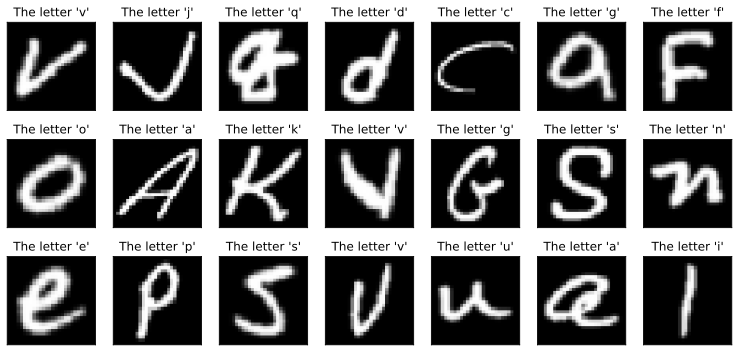

In [9]:
#visualize some images
fig,axs=plt.subplots(3,7,figsize=(13,6))
for i,ax in enumerate(axs.flatten()):
  #pick a random pic
  whichpic=np.random.randint(letterImages.shape[0])
  #extract the images and its target letter
  I=np.squeeze(letterImages[whichpic,:,:])
  letter=letterCategories[labels[whichpic]]

  #visualize
  ax.imshow(I.T,cmap='grey')
  ax.set_title("The letter '%s'"%letter)
  ax.set_xticks([])
  ax.set_yticks([])
plt.show()

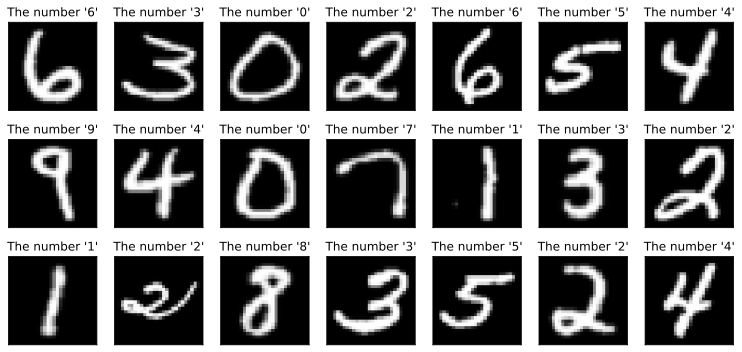

In [11]:
#visualize some images
fig,axs=plt.subplots(3,7,figsize=(13,6))
# Get number categories from numberdata.classes
numberCategories = numberdata.classes

# Get number labels
numberLabels = numberdata.targets

for i,ax in enumerate(axs.flatten()):
  #pick a random pic
  whichpic=np.random.randint(numberImages.shape[0])
  #extract the images and its target letter
  I=np.squeeze(numberImages[whichpic,:,:])
  # Use numberCategories and numberLabels
  number=numberCategories[numberLabels[whichpic]]

  #visualize
  ax.imshow(I.T,cmap='grey')
  ax.set_title("The number '%s'"%number)
  ax.set_xticks([])
  ax.set_yticks([])
plt.show()

Create train/test groups using DataLoader

Create train/test groups using Dataloader

In [14]:
#create a class for the model
def makeTheNet(printtoggle=False):
  class emnistnet(nn.Module):
    def __init__(self,printtoggle):
      super().__init__()
      self.print=printtoggle

      ###-------------feature map layers ------------##
      #first convolution layer
      self.conv1=nn.Conv2d(1,6,3,padding=1)
      self.bnorm1=nn.BatchNorm2d(6)#input the number of channels in this layer
      #output size (28+2*1-3)/1+1=28/2=14(/2 b/c maxpool)
      #second convolution layer
      self.conv2=nn.Conv2d(6,6,3,padding=1)
      self.bnorm2=nn.BatchNorm2d(6)
      #output size:(14+2*1-3)/1 +1=14/2 =7 (/2 b/c maxpool)

      #-----linear decision layers-------###
      self.fc1=nn.Linear(7*7*6,50)
      self.fc2=nn.Linear(50,26)

    def forward(self,x):
      if self.print: print(f'Input :{list(x.shape)}')
      #first block:convolution ->maxpool->batchnorm->relu
      x=F.max_pool2d(self.conv1(x),2)
      x=F.leaky_relu(self.bnorm1(x))
      if self.print: print(f'First CPR block: {list(x.shape)}')

      #second block:convolution->maxpool->batchnorm->relu
      x=F.max_pool2d(self.conv2(x),2)
      x=F.leaky_relu(self.bnorm2(x))
      if self.print: print(f'second CPR block : {list(x.shape)}')

      #reshape for linear layer
      nUnits=x.shape.numel()/x.shape[0]
      x=x.view(-1,int(nUnits))
      if self.print: print(f'Vector before linear layers: {list(x.shape)}')


      #linear layers
      x=F.leaky_relu(self.fc1(x))
      x=self.fc2(x)
      if self.print:print(f'Final output: {list(x.shape)}')

      return x
  #create the model instance
  net=emnistnet(printtoggle)

  #loss fuction
  lossfun=nn.CrossEntropyLoss()

  #optimizer
  optimizer=torch.optim.Adam(net.parameters(),lr=.001)

  return net,lossfun,optimizer

Create a function that trains the model

In [15]:
#a fuction that trains the model
def function2trainTheModel(net,optimizer,train_loader,test_loader,numepochs=10):


  #send the model to the CPU
  net.to(device)

  #initialize losses
  trainLoss=np.zeros(numepochs)
  testLoss=np.zeros(numepochs)
  trainErr=np.zeros(numepochs)
  testErr=np.zeros(numepochs)

  #loop over epochs
  for epochi in range(numepochs):

    #loop over training data batches
    net.train()
    batchLoss=[]
    batchErr=[]
    for X,y in train_loader:
      #push data to GPU
      X=X.to(device)
      y=y.to(device)

      #forward pass and loss
      yHat=net(X)
      loss=lossfun(yHat,y)


      #backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      #loss and error from this batch
      batchLoss.append(loss.item())
      batchErr.append(torch.mean((torch.argmax(yHat,axis=1)!=y).float()).item())
    #end of batch loop...

    #and get average losses and error rates across the batches
    trainLoss[epochi]=np.mean(batchLoss)
    trainErr[epochi]=100*np.mean(batchErr)

    ###test performace
    net.eval()
    X,y=next(iter(test_loader)) #extract X,y from test dataLoader

    #push data to CPU
    X=X.to(device)
    y=y.to(device)

    with torch.no_grad(): #deactivates autograd
      yHat=net(X)
      loss=lossfun(yHat,y)

    testLoss[epochi]=loss.item()
    testErr[epochi]=100*torch.mean((torch.argmax(yHat,axis=1)!=y).float()).item()
  #end epochs

#function output
  return trainLoss,testLoss,trainErr,testErr,net

Run the model and show the results!

In [16]:
#~ 2 minutes with 10 epochs on GPU
letterNet,lossfun,optimizer=makeTheNet(printtoggle=False)
trainLoss,testLoss,trainErr,testErr,net=function2trainTheModel(letterNet,optimizer,letter_train_loader,letter_test_loader,5)


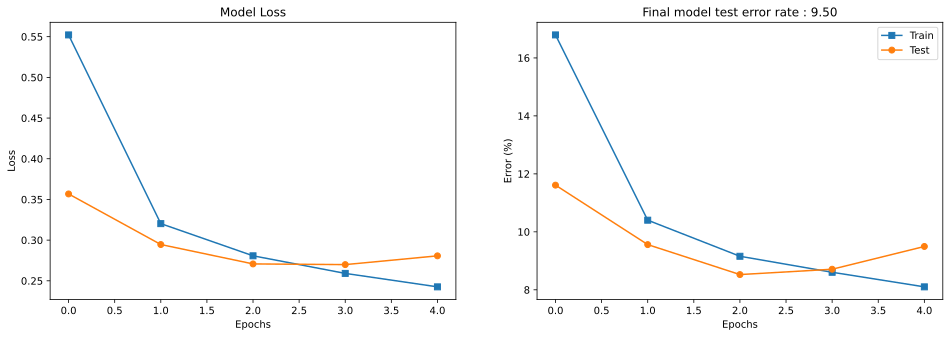

In [17]:
fig,ax=plt.subplots(1,2,figsize=(16,5))

ax[0].plot(trainLoss,'s-',label='Train')
ax[0].plot(testLoss,'o-',label='Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model Loss')

ax[1].plot(trainErr,'s-',label='Train')
ax[1].plot(testErr,'o-',label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Error (%)')
ax[1].set_title(f'Final model test error rate : {testErr[-1]:.2f}')
ax[1].legend()

plt.show()

Test the model on the number data

In [19]:
#extract X,y from Number test dataLoader
X,y=next(iter(number_test_loader))
X=X.to(device)
y=y.to(device)

letterNet.eval()
yHat=letterNet(X)

#the test accuracy
numberAcc=100*torch.mean((torch.argmax(yHat,axis=1)==y).float()).item()
print(f'The model accuracy is {numberAcc:.2f}%')


The model accuracy is 4.88%


Fine-tune the model with one training batch

In [21]:
#create the target model
numberNet,lossfun,optimizer=makeTheNet()
#the replace all the weights in TARGET model from SOURCE model
for target,source in zip(numberNet.named_parameters(),letterNet.named_parameters()):
  target[1].data=copy.deepcopy(source[1].data)


In [22]:
#check out the network
print(numberNet)
print(' ')

#and the final layer
print(numberNet.fc2)
#replace the final layer to have 10 outputs insted of 26
numberNet.fc2=nn.Linear(50,10)
print(' ')
print(numberNet)

emnistnet(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bnorm1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(6, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bnorm2): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=294, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=26, bias=True)
)
 
Linear(in_features=50, out_features=26, bias=True)
 
emnistnet(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bnorm1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(6, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bnorm2): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=294, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
)


In [23]:
#now re-train the network
trainLoss,testLoss,trainErr,testErr,net=function2trainTheModel(numberNet,optimizer,number_train_loader,number_test_loader,5)

In [25]:
#print train and test error rate
print(f'Final train error rate: {trainErr[-1]:.2f}%')
print(f'Final test error rate: {testErr[-1]:.2f}%')

Final train error rate: 0.81%
Final test error rate: 0.85%


Try again,only train output layer

In [26]:
#create the target model
numberNet2,lossfun,optimizer=makeTheNet()
#the replace all the weights in TARGET model from SOURCE model
for target,source in zip(numberNet2.named_parameters(),letterNet.named_parameters()):
  target[1].data=copy.deepcopy(source[1].data)
#adjust number of output units
numberNet2.fc2=nn.Linear(50,10)
#freeze convolution and batch-norm layers
for p in numberNet2.named_parameters():
  if 'conv' in p[0] or 'bnorm' in p[0]:
    p[1].requires_grad=False




Accuracy by letter

In [27]:
trainLoss,testLoss,trainErr,testErr,net=function2trainTheModel(numberNet2,optimizer,number_train_loader,number_test_loader,5)

In [28]:
print(f'Final train error rate: {trainErr[-1]:.2f}%')
print(f'Final test error rate: {testErr[-1]:.2f}%')

Final train error rate: 0.81%
Final test error rate: 0.88%
